In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch


print("numpy: ", np.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
torch:  2.8.0+cu126


環境を自作する

In [2]:
MAX_INVENTORY = 100
MAX_STEP_COUNT = 31
STATE = np.array([1.0, 1.0],  # 状態(観察)は[残り在庫の割合, 残りステップの割合]で表現する
                 dtype=np.float32)
PRICE_FOR_ACTION = np.array([100, 120, 140, 160, 180])  # 行動は取り得る価格を選択する事として、取り得る価格は5次元ベクトルで表現する

In [3]:
class PriceEnvironment():
    def __init__(self, max_inventory, max_step_count):
        self.max_inventory = max_inventory
        self.inventory = self.max_inventory
        self.max_step_count = max_step_count
        self.step_count = 0
        self.price_array = PRICE_FOR_ACTION

    def step(self, action_number):
        price = self.price_array[action_number]
        demand_expectation = int((PRICE_FOR_ACTION[-1] / price) * (self.inventory * 0.05))  # 「在庫の5%」×「重み」を「需要の期待値」とする # 「重み」は、最高価格に対する価格の割合の逆数(価格が高いと重みは小さい)とする
        demand = np.random.poisson(lam=demand_expectation,  # 「需要の期待値」を「ポアソン分布の期待値」として、ポアソン分布から「需要」を確率的に得る
                                   size=None)  # 引数sizeをNoneにする事でポアソン分布から1個だけの値を確率的に得る # sizeを100にすると100個の値を確率的に得る形になる
        saled_inventory = min(self.inventory, max(demand, 0))  # 「売れた在庫」は、「需要」と「在庫数」の小さい方の値とする # 「在庫数」以上の「需要」は売れないため
        reward = price * saled_inventory
        self.inventory = self.inventory - saled_inventory
        inventory_ratio = self.inventory / self.max_inventory
        self.step_count = self.step_count + 1
        step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        if self.inventory <= 0 or self.step_count >= self.max_step_count:
            done = 1
        else:
            done = 0
        next_state = np.array([inventory_ratio, step_ratio],
                              dtype=np.float32)
        return reward, next_state, done

    def reset(self):
        self.inventory = self.max_inventory
        self.step_count = 0
        state = STATE
        done = 0
        return state, done

Actor-Criticモデル

In [13]:
class MyActor(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=action_dim)

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(input=self.layer_1(input=in_data))
        out_layer_2 = torch.nn.functional.softmax(input=self.layer_2(input=out_layer_1),
                                                  dim=-1)  # softmax計算をどの軸で行うか
        return out_layer_2


class MyCritic(torch.nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=1)

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(input=self.layer_1(input=in_data))
        out_layer_2 = self.layer_2(input=out_layer_1)
        return out_layer_2

学習

In [14]:
def update_critic(state_list, next_state_list, reward_list, done_list):
    # モンテカルロ法
    returns_list = []
    G = 0
    for reward, done in reversed(list(zip(reward_list, done_list))):  # Criticの正解データ(target)はモンテカルロ法で算出する
        if done == 1:
            G = reward
        else:
            G = reward + GAMMA * G
        returns_list.insert(0, G)
    target_value_batch = torch.Tensor(np.array(returns_list)).unsqueeze(dim=1)  # (N, 1)
    # TD法
    # next_state_batch = torch.stack(next_state_list, dim=0).squeeze(dim=1)  # (N, 2)
    # next_state_value_batch = nn_critic_model(in_data=next_state_batch)  # (N, 1)
    # reward_batch = torch.Tensor(np.array(reward_list)).unsqueeze(dim=1)  # (N, 1)
    # done_batch = torch.Tensor(np.array(done_list)).unsqueeze(dim=1)  # (N, 1)
    # target_value_batch = reward_batch + (GAMMA * next_state_value_batch) * (1 - done_batch)  # (N, 1) # Criticの正解データ(target) # doneが1の時はnext_state_valueを考慮しない
    target_value_batch = target_value_batch.detach()
    state_batch = torch.stack(state_list, dim=0).squeeze(dim=1)  # (N, 2)
    state_value_batch = nn_critic_model(in_data=state_batch)  # (N, 1) # Criticの推論データ
    loss_batch_for_critic = critic_loss(input=state_value_batch,  # Criticの損失値 # スカラー値 # ミニバッチの平均になる
                                        target=target_value_batch)
    critic_optimizer.zero_grad()
    loss_batch_for_critic.backward()
    critic_optimizer.step()
    delta_batch = target_value_batch - state_value_batch  # (N, 1) # Actorの損失値を計算する時に使う # R + γV(St+1) - V(St)
    delta_batch = delta_batch.detach()
    return delta_batch


def update_actor(action_list, state_list, pi_old, delta_batch):
    state_batch = torch.stack(state_list, dim=0).squeeze(dim=1)  # (N, 2)
    action_probs_new_batch = nn_actor_model(in_data=state_batch)  # (N, 5) # πθ(St)
    action_prob_new_list = [action_probs_new_batch[i, action_list[i]] for i in range(len(action_list))]
    action_prob_new_batch = torch.stack(action_prob_new_list, dim=0).unsqueeze(dim=1)  # (N, 1) # πθ(At│St)
    action_prob_old_list = [pi_old[i, action_list[i]] for i in range(len(action_list))]
    action_prob_old_batch = torch.stack(action_prob_old_list, dim=0).unsqueeze(dim=1)  # (N, 1) # πoldθ(At│St)
    action_prob_ratio_batch = action_prob_new_batch / action_prob_old_batch  # (N, 1) # Actorの損失値の計算で使う確率比率
    action_prob_ratio_clip_batch = torch.clamp(input=action_prob_ratio_batch,  # (N, 1) # Actorの損失値の計算で使う確率比率のクリップ
                                               min=1 - PPO_EPSILON,
                                               max=1 + PPO_EPSILON)
    losses_batch_for_actor = torch.min(action_prob_ratio_batch * delta_batch,  # (N, 1) # Actorの損失値
                                       action_prob_ratio_clip_batch * delta_batch)
    loss_batch_for_actor = - losses_batch_for_actor.mean()  # スカラー値 # ミニバッチの平均にする # 符号を逆にして目的関数を損失関数扱いにする
    actor_optimizer.zero_grad()
    loss_batch_for_actor.backward()
    actor_optimizer.step()
    return None


def update_policy(datas, epochs):
    action_list = [data["action"] for data in datas]  # 1エピソード分のステップ数(以下N)
    state_list = [torch.Tensor(data["state"]) for data in datas]
    next_state_list = [torch.Tensor(data["next_state"]) for data in datas]
    reward_list = [data["reward"] for data in datas]
    done_list = [data["done"] for data in datas]
    state_batch = torch.stack(state_list, dim=0).squeeze(dim=1)
    pi_old = nn_actor_model(in_data=state_batch).detach()  # 学習前のActorの出力を旧方策πoldθ(St)とする # ステップ間で勾配を共有しないようにdetach()する
    for epoch in range(epochs):
        delta_batch = update_critic(state_list=state_list,
                                    next_state_list=next_state_list,
                                    reward_list=reward_list,
                                    done_list=done_list)
        update_actor(action_list=action_list,
                     state_list=state_list,
                     pi_old=pi_old,
                     delta_batch=delta_batch)
    return None

In [15]:
nn_actor_model = MyActor(state_dim=len(STATE),
                         action_dim=len(PRICE_FOR_ACTION))
nn_critic_model = MyCritic(state_dim=len(STATE))
actor_optimizer = torch.optim.Adam(params=nn_actor_model.parameters(),
                                   lr=0.001)
critic_optimizer = torch.optim.Adam(params=nn_critic_model.parameters(),
                                    lr=0.001)
critic_loss = torch.nn.MSELoss()
nn_actor_model.train()
nn_critic_model.train()
env = PriceEnvironment(max_inventory=MAX_INVENTORY,
                       max_step_count=MAX_STEP_COUNT)
GAMMA = 0.98  # 割引率
PPO_EPSILON = 0.2  # クリップ
total_reward_list = []
for episode in range(2000):
    state, done = env.reset()
    total_reward = 0
    data_dict_list = []
    while done == 0:
        state_tensor = torch.unsqueeze(input=torch.tensor(state),  # ニューラルネットワークモデルに入力できるようにミニバッチ軸を追加
                                       dim=0)
        action_probs_new = nn_actor_model(in_data=state_tensor)  # Actorの推論データ # 今時点の新方策πθ
        action_probs_new = action_probs_new.squeeze(dim=0)
        probs = action_probs_new.detach().numpy()
        action = np.random.choice(a=len(PRICE_FOR_ACTION),  # 取り得る値の候補 # arrayでなくスカラーの場合はrange(a)を候補とする
                                  p=probs/probs.sum())  # 合計値を確実に1にする
        reward, next_state, done = env.step(action_number=action)
        data_dict = {"state": state,
                     "action": action,
                     "reward": reward,
                     "next_state": next_state,
                     "done": done}
        data_dict_list.append(data_dict)
        state = next_state
        total_reward = total_reward + reward
    total_reward_list.append(total_reward)
    update_policy(datas=data_dict_list,
                  epochs=5)

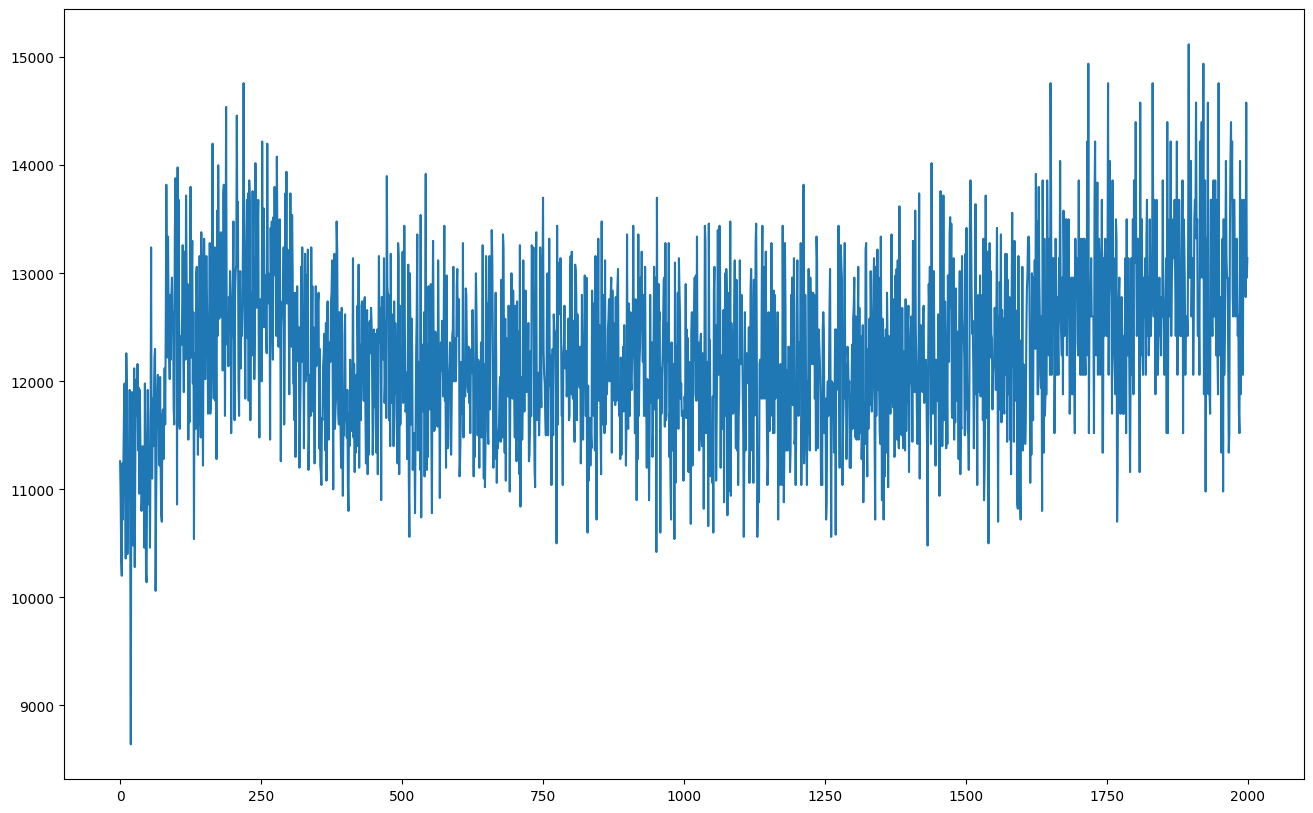

In [16]:
plt.figure(figsize=(16, 10))
plt.plot(range(len(total_reward_list)),
         total_reward_list)
plt.show()